In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.stats import uniform, loguniform
from ydata_profiling import ProfileReport
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix, 
                             accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, roc_curve)
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

from utils.data_loader import load_bank_churn_data

/Users/juanse/Documents/AI/analytics-project/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = load_bank_churn_data()
df.head()

Cargando datos desde: data/raw/bank_churn.xlsx
Datos cargados: 10127 filas, 21 columnas


,clientnum,attrition_flag,customer_age,gender,dependent_count,education_level,marital_status,income_category,card_category,months_on_book,...,months_inactive_12_mon,contacts_count_12_mon,credit_limit,total_revolving_bal,avg_open_to_buy,total_amt_chng_q4_q1,total_trans_amt,total_trans_ct,total_ct_chng_q4_q1,avg_utilization_ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


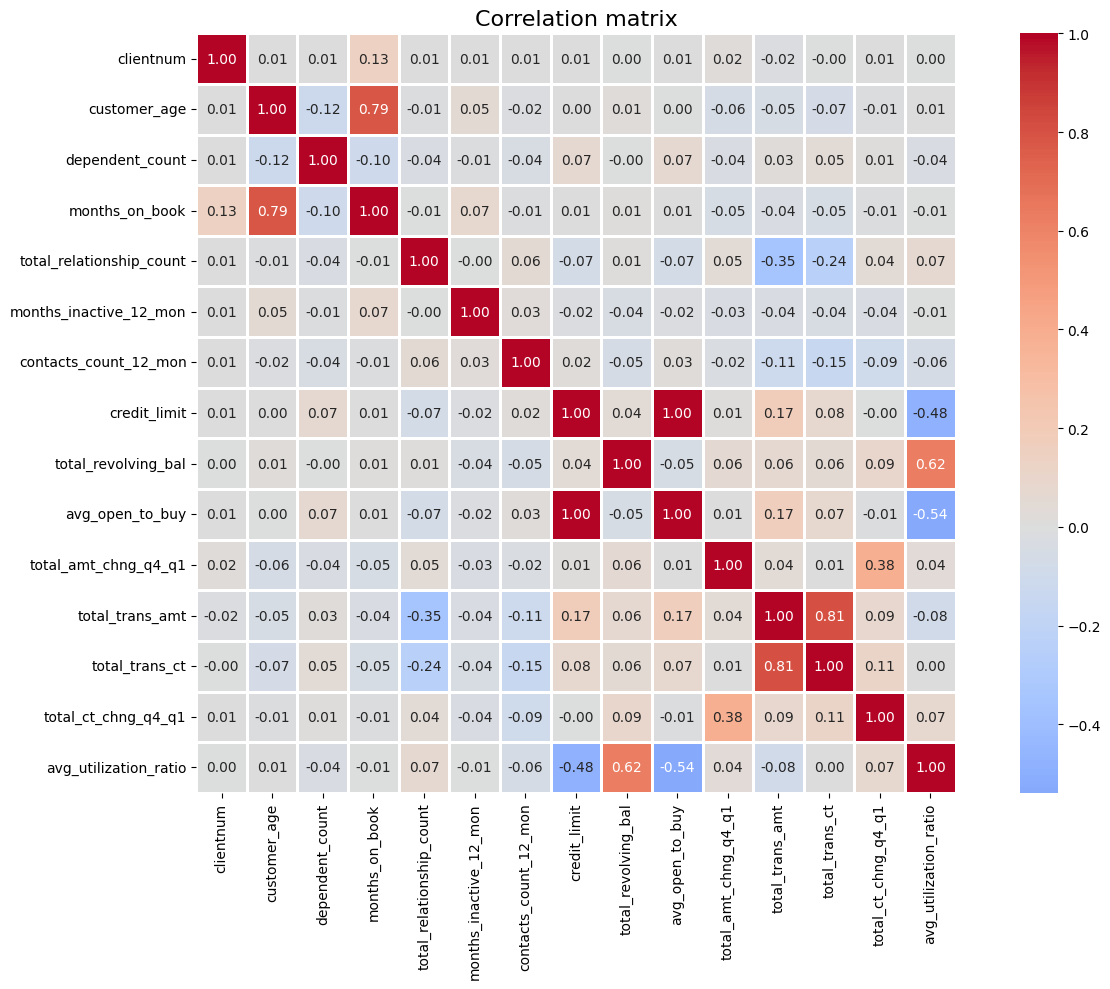


Top correlations with total_trans_amt:
total_trans_amt           1.000000
total_trans_ct            0.807192
credit_limit              0.171730
avg_open_to_buy           0.165923
total_ct_chng_q4_q1       0.085581
total_revolving_bal       0.064370
total_amt_chng_q4_q1      0.039678
dependent_count           0.025046
clientnum                -0.019692
months_inactive_12_mon   -0.036982
Name: total_trans_amt, dtype: float64


In [3]:
# Select only numerical variables
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# Correlation matrix
plt.figure(figsize=(14, 10))
correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1)
plt.title('Correlation matrix', fontsize=16)
plt.tight_layout()
plt.show()

# Top correlations with important variables
print("\nTop correlations with total_trans_amt:")
print(correlation_matrix['total_trans_amt'].sort_values(ascending=False).head(10))

In [4]:
# Drop useless and high correlation variables
columns_to_drop = ['clientnum', 'credit_limit', 
                   'total_trans_amt', 'total_amt_chng_q4_q1', 'total_revolving_bal']

df = df.drop(columns=columns_to_drop)

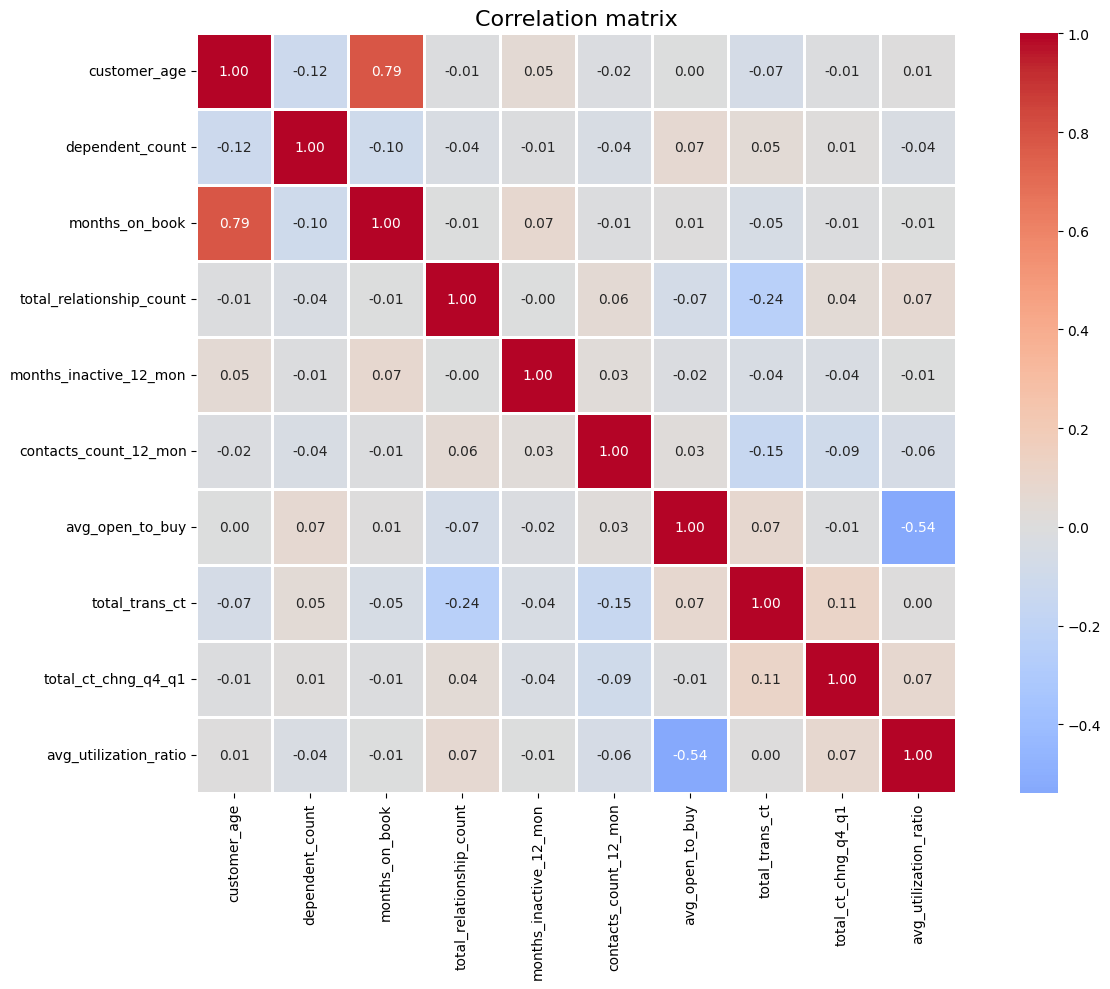

In [5]:
# Select only numerical variables
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# Correlation matrix
plt.figure(figsize=(14, 10))
correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1)
plt.title('Correlation matrix', fontsize=16)
plt.tight_layout()
plt.show()

In [6]:
# Create target variable (1 = Churn, 0 = No Churn)
df['churn'] = (df['attrition_flag'] == 'Attrited Customer').astype(int)

# Drop original column
df = df.drop('attrition_flag', axis=1)

# check distribution
print("Distribución de Churn:")
print(df['churn'].value_counts())
print("\nPorcentaje:")
print(df['churn'].value_counts(normalize=True))

Distribución de Churn:
churn
0    8500
1    1627
Name: count, dtype: int64

Porcentaje:
churn
0    0.83934
1    0.16066
Name: proportion, dtype: float64


In [8]:
# one-hot encoding for categorical variables (except 'churn')
categorical_cols = ['gender', 'education_level', 'marital_status',
                    'income_category', 'card_category']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)


In [9]:
print(df.columns.tolist())

['customer_age', 'dependent_count', 'months_on_book', 'total_relationship_count', 'months_inactive_12_mon', 'contacts_count_12_mon', 'avg_open_to_buy', 'total_trans_ct', 'total_ct_chng_q4_q1', 'avg_utilization_ratio', 'churn', 'gender_M', 'education_level_Doctorate', 'education_level_Graduate', 'education_level_High School', 'education_level_Post-Graduate', 'education_level_Uneducated', 'education_level_Unknown', 'marital_status_Married', 'marital_status_Single', 'marital_status_Unknown', 'income_category_$40K - $60K', 'income_category_$60K - $80K', 'income_category_$80K - $120K', 'income_category_Less than $40K', 'income_category_Unknown', 'card_category_Gold', 'card_category_Platinum', 'card_category_Silver']


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 29 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   customer_age                    10127 non-null  int64  
 1   dependent_count                 10127 non-null  int64  
 2   months_on_book                  10127 non-null  int64  
 3   total_relationship_count        10127 non-null  int64  
 4   months_inactive_12_mon          10127 non-null  int64  
 5   contacts_count_12_mon           10127 non-null  int64  
 6   avg_open_to_buy                 10127 non-null  float64
 7   total_trans_ct                  10127 non-null  int64  
 8   total_ct_chng_q4_q1             10127 non-null  float64
 9   avg_utilization_ratio           10127 non-null  float64
 10  churn                           10127 non-null  int64  
 11  gender_M                        10127 non-null  bool   
 12  education_level_Doctorate       

In [11]:
y = df['churn']
X = df.drop(columns=['churn'])  # Eliminar la variable objetivo

#Dividir en train y test (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [12]:
numerical_cols = ['customer_age', 'dependent_count', 'months_on_book', 
                   'total_relationship_count', 'months_inactive_12_mon', 
                   'contacts_count_12_mon', 'avg_open_to_buy', 
                   'total_trans_ct', 'total_ct_chng_q4_q1','avg_utilization_ratio']

# 4. Estandarizar SOLO las columnas numéricas
scaler = StandardScaler()

# Crear copias para no modificar los originales
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Estandarizar solo las columnas numéricas
X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])

In [13]:
X_train_scaled.head()

,customer_age,dependent_count,months_on_book,total_relationship_count,months_inactive_12_mon,contacts_count_12_mon,avg_open_to_buy,total_trans_ct,total_ct_chng_q4_q1,avg_utilization_ratio,...,marital_status_Single,marital_status_Unknown,income_category_$40K - $60K,income_category_$60K - $80K,income_category_$80K - $120K,income_category_Less than $40K,income_category_Unknown,card_category_Gold,card_category_Platinum,card_category_Silver
2856,-1.301232,-1.809900,-1.513205,0.122196,0.646495,-0.411236,-0.783057,-0.961644,-1.093573,2.148867,...,False,False,False,False,False,True,False,False,False,False
6515,-0.299340,0.501503,-0.000700,0.765411,-0.342413,0.489635,1.977862,-1.131083,-0.537244,-1.000072,...,True,False,False,True,False,False,False,False,False,True
7141,-0.048867,-0.268965,-0.756952,1.408625,0.646495,-1.312106,0.370094,1.029259,0.579534,-0.717103,...,False,False,False,False,True,False,False,False,False,False
632,-1.301232,-0.268965,-1.513205,-0.521019,-1.331320,0.489635,-0.651190,-1.004004,-1.427370,0.850111,...,False,False,False,False,False,True,False,False,False,False
3496,0.452079,-1.039432,0.503468,0.122196,-0.342413,0.489635,2.869713,0.309145,0.002601,-0.876727,...,True,False,False,False,False,False,False,False,False,False
